# Predict best medication for feaver!

In this notebook we will explore data about patients that got fever

In [ ]:
# Data tools
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Read in data

In [2]:
df = pd.read_csv("fever.csv")

## EDA

In [3]:
df.head()

,Temperature,Fever_Severity,Age,Gender,BMI,Headache,Body_Ache,Fatigue,Chronic_Conditions,Allergies,Smoking_History,Alcohol_Consumption,Humidity,AQI,Physical_Activity,Diet_Type,Heart_Rate,Blood_Pressure,Previous_Medication,Recommended_Medication
0,36.1,Normal,89,Female,24.0,No,Yes,No,No,Yes,No,Yes,81.4,430,Moderate,Vegan,72,Normal,NaN,Ibuprofen
1,37.5,Mild Fever,94,Male,26.6,No,No,No,Yes,No,Yes,Yes,44.4,10,Active,Vegetarian,62,High,Ibuprofen,Paracetamol
2,36.4,Normal,92,Male,27.8,No,No,No,No,No,No,Yes,73.7,400,Sedentary,Vegan,85,High,NaN,Ibuprofen
3,39.8,High Fever,66,Male,18.7,No,Yes,No,No,No,No,No,44.1,438,Active,Non-Vegetarian,96,High,Ibuprofen,Ibuprofen
4,39.3,High Fever,28,Male,21.0,No,Yes,No,Yes,Yes,Yes,Yes,65.9,451,Active,Vegetarian,85,Low,Paracetamol,Ibuprofen


In [4]:
df.shape

(1000, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature             1000 non-null   float64
 1   Fever_Severity          1000 non-null   object 
 2   Age                     1000 non-null   int64  
 3   Gender                  1000 non-null   object 
 4   BMI                     1000 non-null   float64
 5   Headache                1000 non-null   object 
 6   Body_Ache               1000 non-null   object 
 7   Fatigue                 1000 non-null   object 
 8   Chronic_Conditions      1000 non-null   object 
 9   Allergies               1000 non-null   object 
 10  Smoking_History         1000 non-null   object 
 11  Alcohol_Consumption     1000 non-null   object 
 12  Humidity                1000 non-null   float64
 13  AQI                     1000 non-null   int64  
 14  Physical_Activity       1000 non-null   o

In [7]:
df.Fever_Severity.value_counts()

Fever_Severity
High Fever    532
Normal        269
Mild Fever    199
Name: count, dtype: int64

Fever_Severity
High Fever    Axes(0.125,0.11;0.775x0.77)
Mild Fever    Axes(0.125,0.11;0.775x0.77)
Normal        Axes(0.125,0.11;0.775x0.77)
Name: Temperature, dtype: object

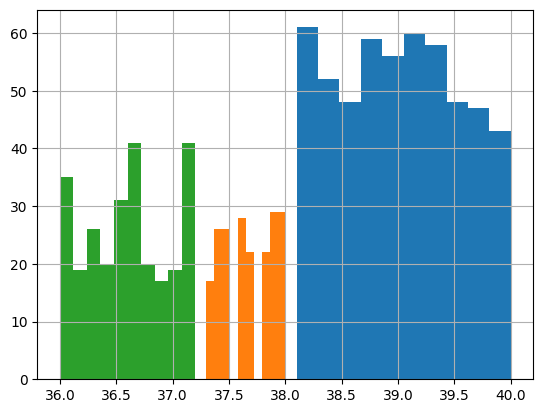

In [9]:
df.groupby("Fever_Severity")["Temperature"].hist()

array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'Humidity'}>],
       [<Axes: title={'center': 'AQI'}>,
        <Axes: title={'center': 'Heart_Rate'}>]], dtype=object)

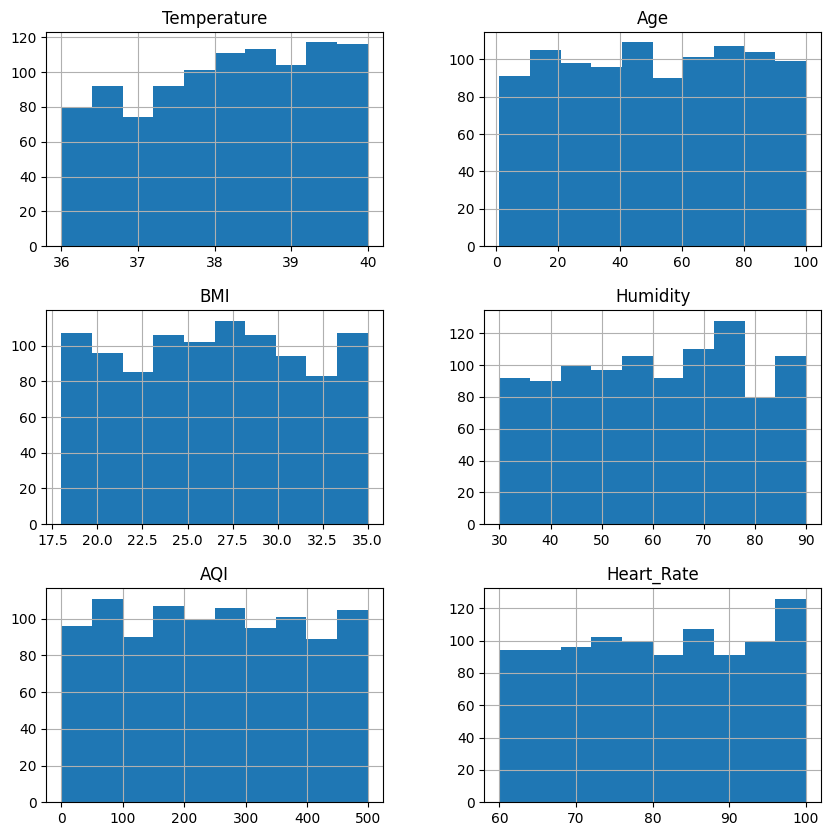

In [6]:
df.hist(figsize=(10,10))

array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'Age'}>, <Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'Humidity'}>,
        <Axes: title={'center': 'AQI'}>,
        <Axes: title={'center': 'Heart_Rate'}>]], dtype=object)

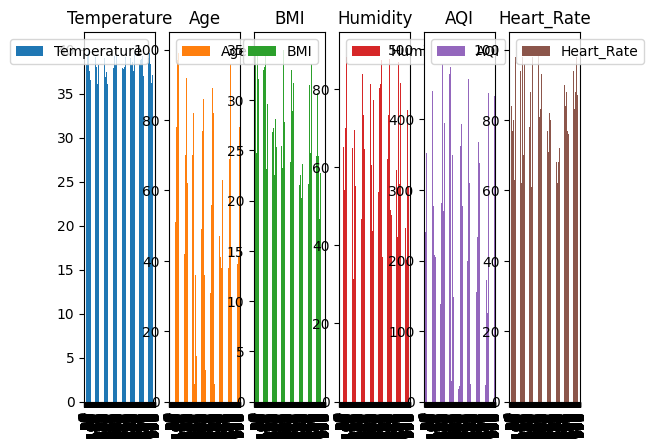

In [ ]:
# df.plot(kind="bar", subplots=True, layout=(1,6))

In [15]:
df.nunique()

Temperature                41
Fever_Severity              3
Age                       100
Gender                      2
BMI                       170
Headache                    2
Body_Ache                   2
Fatigue                     2
Chronic_Conditions          2
Allergies                   2
Smoking_History             2
Alcohol_Consumption         2
Humidity                  489
AQI                       428
Physical_Activity           3
Diet_Type                   3
Heart_Rate                 41
Blood_Pressure              3
Previous_Medication         3
Recommended_Medication      2
dtype: int64

## Data preprocessing

In [14]:
df.columns

Index(['Temperature', 'Fever_Severity', 'Age', 'Gender', 'BMI', 'Headache',
       'Body_Ache', 'Fatigue', 'Chronic_Conditions', 'Allergies',
       'Smoking_History', 'Alcohol_Consumption', 'Humidity', 'AQI',
       'Physical_Activity', 'Diet_Type', 'Heart_Rate', 'Blood_Pressure',
       'Previous_Medication', 'Recommended_Medication'],
      dtype='object')

In [16]:
sub_df = df[['Temperature', 'Age', 'Gender', 'Headache',
       'Body_Ache', 'Fatigue', 'Smoking_History', 'Physical_Activity', 'Recommended_Medication']]

In [18]:
sub_df.head()

,Temperature,Age,Gender,Headache,Body_Ache,Fatigue,Smoking_History,Physical_Activity,Recommended_Medication
0,36.1,89,Female,No,Yes,No,No,Moderate,Ibuprofen
1,37.5,94,Male,No,No,No,Yes,Active,Paracetamol
2,36.4,92,Male,No,No,No,No,Sedentary,Ibuprofen
3,39.8,66,Male,No,Yes,No,No,Active,Ibuprofen
4,39.3,28,Male,No,Yes,No,Yes,Active,Ibuprofen


In [19]:
sub_df["Gender"] = sub_df["Gender"].map({"Female":0, "Male":1})
sub_df["Headache"] = sub_df["Headache"].map({"No":0, "Yes":1})
sub_df["Body_Ache"] = sub_df["Body_Ache"].map({"No":0, "Yes":1})
sub_df["Fatigue"] = sub_df["Fatigue"].map({"No":0, "Yes":1})
sub_df["Smoking_History"] = sub_df["Smoking_History"].map({"No":0, "Yes":1})
sub_df["Physical_Activity"] = sub_df["Physical_Activity"].map({"Sedentary":0, "Moderate":1, "Active":2})


C:\Users\Sebastian\AppData\Local\Temp\ipykernel_19860\3799047087.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["Gender"] = sub_df["Gender"].map({"Female":0, "Male":1})
C:\Users\Sebastian\AppData\Local\Temp\ipykernel_19860\3799047087.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["Headache"] = sub_df["Headache"].map({"No":0, "Yes":1})
C:\Users\Sebastian\AppData\Local\Temp\ipykernel_19860\3799047087.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [21]:
sub_df["Recommended_Medication"] = sub_df["Recommended_Medication"].map({"Ibuprofen":0, "Paracetamol":1})

C:\Users\Sebastian\AppData\Local\Temp\ipykernel_19860\2307583258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["Recommended_Medication"] = sub_df["Recommended_Medication"].map({"Ibuprofen":0, "Paracetamol":1})


In [22]:
sub_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature             1000 non-null   float64
 1   Age                     1000 non-null   int64  
 2   Gender                  1000 non-null   int64  
 3   Headache                1000 non-null   int64  
 4   Body_Ache               1000 non-null   int64  
 5   Fatigue                 1000 non-null   int64  
 6   Smoking_History         1000 non-null   int64  
 7   Physical_Activity       1000 non-null   int64  
 8   Recommended_Medication  1000 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 70.4 KB


array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>],
       [<Axes: title={'center': 'Headache'}>,
        <Axes: title={'center': 'Body_Ache'}>,
        <Axes: title={'center': 'Fatigue'}>],
       [<Axes: title={'center': 'Smoking_History'}>,
        <Axes: title={'center': 'Physical_Activity'}>,
        <Axes: title={'center': 'Recommended_Medication'}>]], dtype=object)

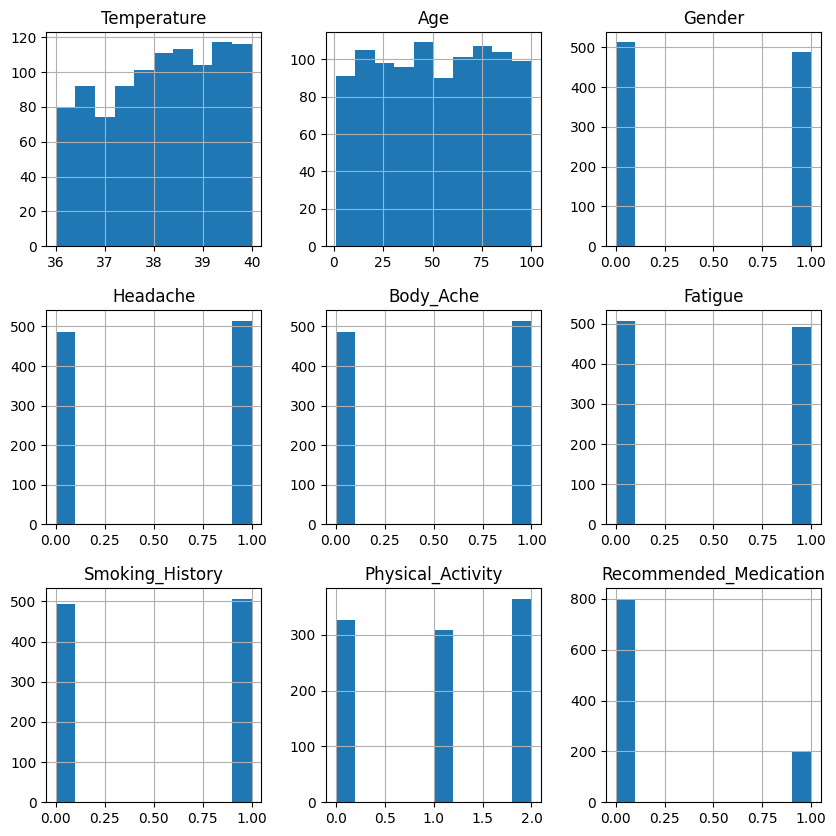

In [47]:
sub_df.hist(figsize=(10,10))

In [25]:
sub_df.corr()

,Temperature,Age,Gender,Headache,Body_Ache,Fatigue,Smoking_History,Physical_Activity,Recommended_Medication
Temperature,1.000000,-0.034607,-0.009426,0.011015,-0.017285,-0.010295,0.007130,-0.026914,-0.187652
Age,-0.034607,1.000000,0.013922,-0.003625,0.025634,0.018937,0.001867,-0.010999,0.057521
Gender,-0.009426,0.013922,1.000000,0.010728,-0.033305,-0.044402,-0.017671,-0.025384,-0.010583
Headache,0.011015,-0.003625,0.010728,1.000000,-0.008908,0.046507,0.059613,-0.076015,-0.017466
Body_Ache,-0.017285,0.025634,-0.033305,-0.008908,1.000000,0.022493,-0.040442,0.046784,0.067733
Fatigue,-0.010295,0.018937,-0.044402,0.046507,0.022493,1.000000,-0.033784,-0.025746,-0.044630
Smoking_History,0.007130,0.001867,-0.017671,0.059613,-0.040442,-0.033784,1.000000,0.028244,0.020576
Physical_Activity,-0.026914,-0.010999,-0.025384,-0.076015,0.046784,-0.025746,0.028244,1.000000,-0.019779
Recommended_Medication,-0.187652,0.057521,-0.010583,-0.017466,0.067733,-0.044630,0.020576,-0.019779,1.000000


<Axes: >

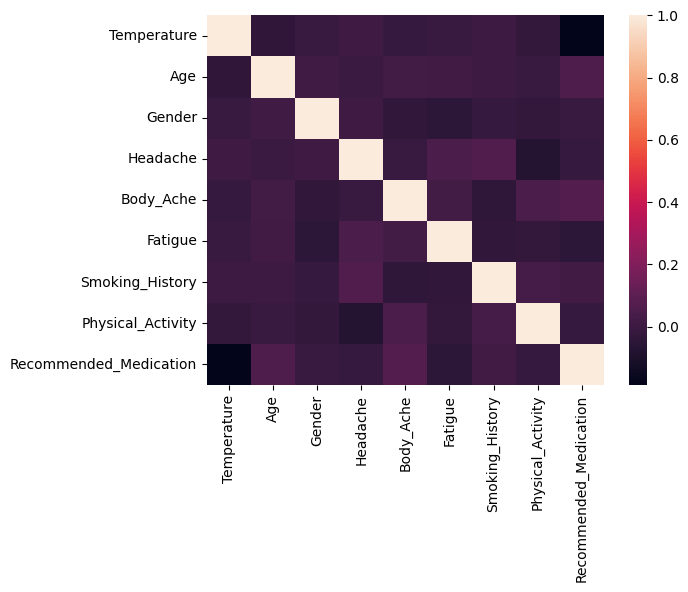

In [24]:
sns.heatmap(sub_df.corr())

In [41]:
X, y = sub_df.drop(columns=["Recommended_Medication"]), df["Recommended_Medication"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Train some models

In [42]:
lg_clf = LogisticRegression()
lg_clf.fit(X_train, y_train)
lg_predict = lg_clf.predict(X_test)
print(classification_report(y_test, lg_predict))

              precision    recall  f1-score   support

   Ibuprofen       0.80      1.00      0.89       160
 Paracetamol       0.00      0.00      0.00        40

    accuracy                           0.80       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.64      0.80      0.71       200



c:\Users\Sebastian\Systementor\EC\Kortkurser\PythonprogrammeringMedAi\Lektioner\EOBPAH25KD_Lektion_12\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Sebastian\Systementor\EC\Kortkurser\PythonprogrammeringMedAi\Lektioner\EOBPAH25KD_Lektion_12\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
 

In [43]:
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
dt_predict = dt_clf.predict(X_test)
print(classification_report(y_test, dt_predict))

              precision    recall  f1-score   support

   Ibuprofen       1.00      1.00      1.00       160
 Paracetamol       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



[Text(0.6, 0.8333333333333334, 'Temperature <= 38.05\ngini = 0.318\nsamples = 800\nvalue = [641, 159]'),
 Text(0.4, 0.5, 'Temperature <= 37.25\ngini = 0.488\nsamples = 375\nvalue = [216.0, 159.0]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 216\nvalue = [216, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 159\nvalue = [0, 159]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 425\nvalue = [425, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

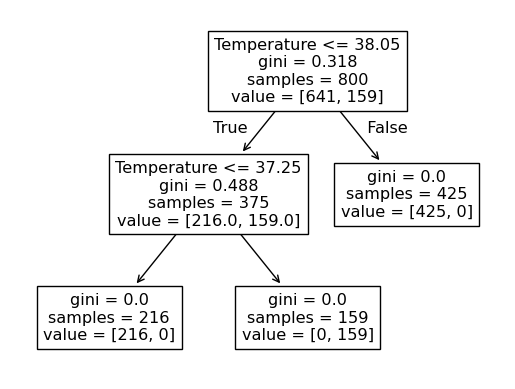

In [45]:
tree.plot_tree(dt_clf, feature_names=dt_clf.feature_names_in_) 

In [44]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
rf_predict = rf_clf.predict(X_test)
print(classification_report(y_test, rf_predict))

              precision    recall  f1-score   support

   Ibuprofen       1.00      0.99      1.00       160
 Paracetamol       0.98      1.00      0.99        40

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [48]:

cm = confusion_matrix(y_test, rf_clf.predict(X_test))

print('Confusion matrix\n\n', cm)

Confusion matrix

 [[159   1]
 [  0  40]]
